# MIMIC-Extract Experiment Statistics
This notebook visualizes the number of entries (ICU stays) and the statistics (mean, median, standard deviation) for the clinical variables across the different extraction scenarios.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.2)

# Load the computed statistics
with open('../experiment_stats.json', 'r') as f:
    stats_raw = json.load(f)

# Keep a single baseline in visualizations
EXCLUDED_EXPERIMENTS = {'baseline_nofilters_fast'}
stats = {k: v for k, v in stats_raw.items() if k not in EXCLUDED_EXPERIMENTS}

print(f"Loaded stats for {len(stats_raw)} experiments ({len(stats)} plotted after filtering).")
if EXCLUDED_EXPERIMENTS & set(stats_raw):
    print(f"Excluded from plots: {sorted(EXCLUDED_EXPERIMENTS & set(stats_raw))}")

# Explain minperc5 count if it matches baseline
if 'baseline_nofilters' in stats and 'minperc5' in stats:
    n_base = stats['baseline_nofilters']['num_entries']
    n_minp = stats['minperc5']['num_entries']
    if n_base == n_minp:
        print(
            f"minperc5 and baseline_nofilters both have {n_base} stays. "
        )



Loaded stats for 14 experiments (13 plotted after filtering).
Excluded from plots: ['baseline_nofilters_fast']
minperc5 and baseline_nofilters both have 34472 stays. 


## 1. Number of Entries per Experiment

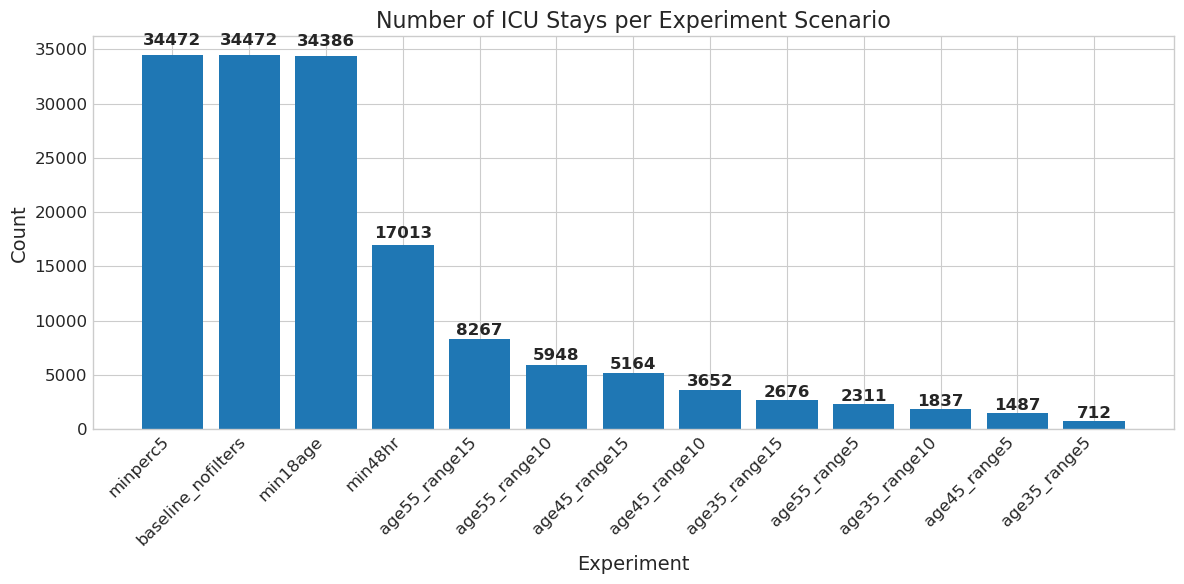

In [2]:
entries = {exp: data['num_entries'] for exp, data in stats.items()}
df_entries = pd.DataFrame.from_dict(entries, orient='index', columns=['Number of Entries'])
df_entries = df_entries.sort_values('Number of Entries', ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=df_entries.index, y=df_entries['Number of Entries'], palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Number of ICU Stays per Experiment Scenario', fontsize=16)
plt.ylabel('Count', fontsize=14)
plt.xlabel('Experiment', fontsize=14)

# Add value labels on top of bars
for i, v in enumerate(df_entries['Number of Entries']):
    ax.text(i, v + (v*0.02), str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()



## 2. Clinical Variable Statistics
Let's look at the mean and standard deviation for a few key vital signs across the different experiments.

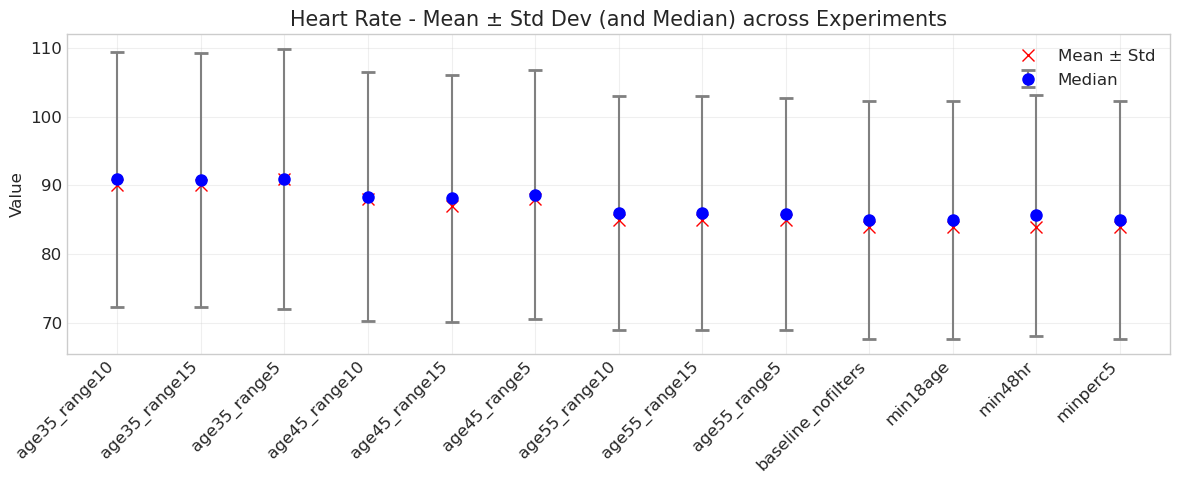

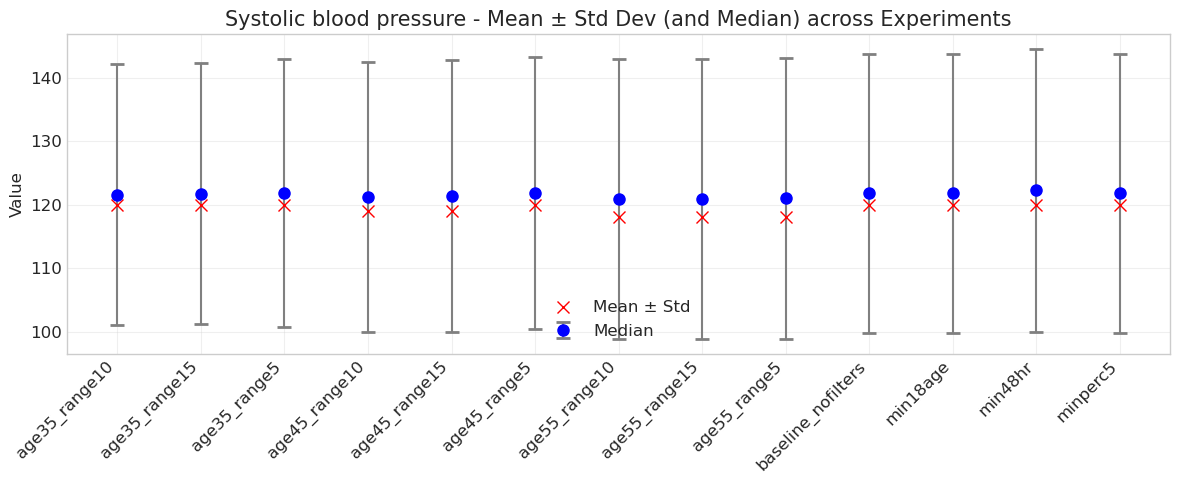

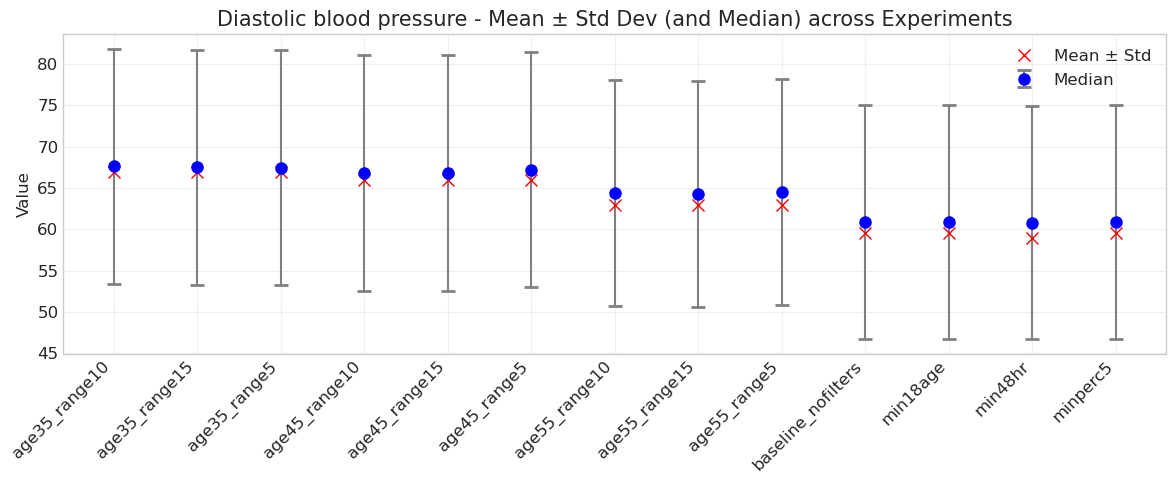

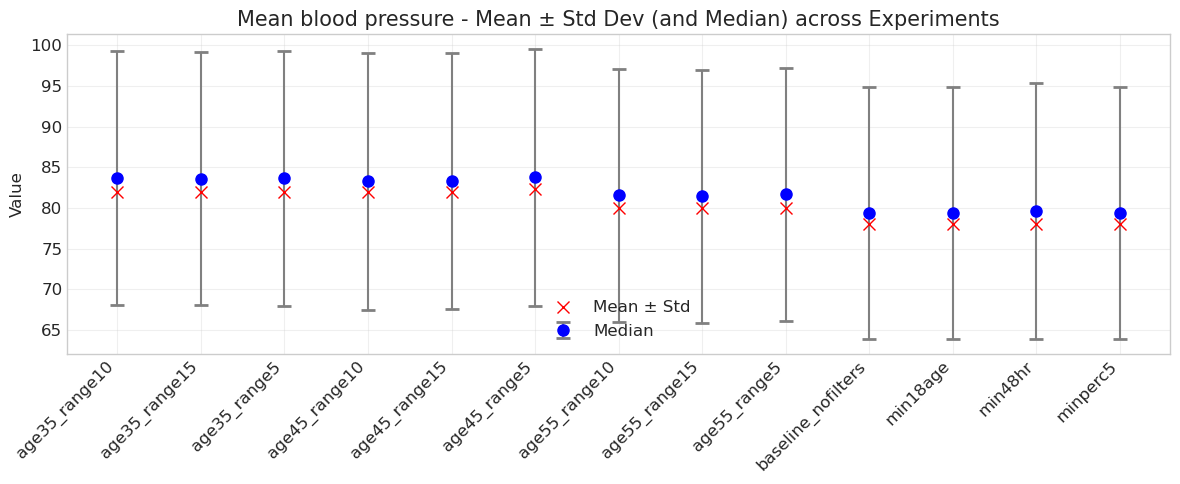

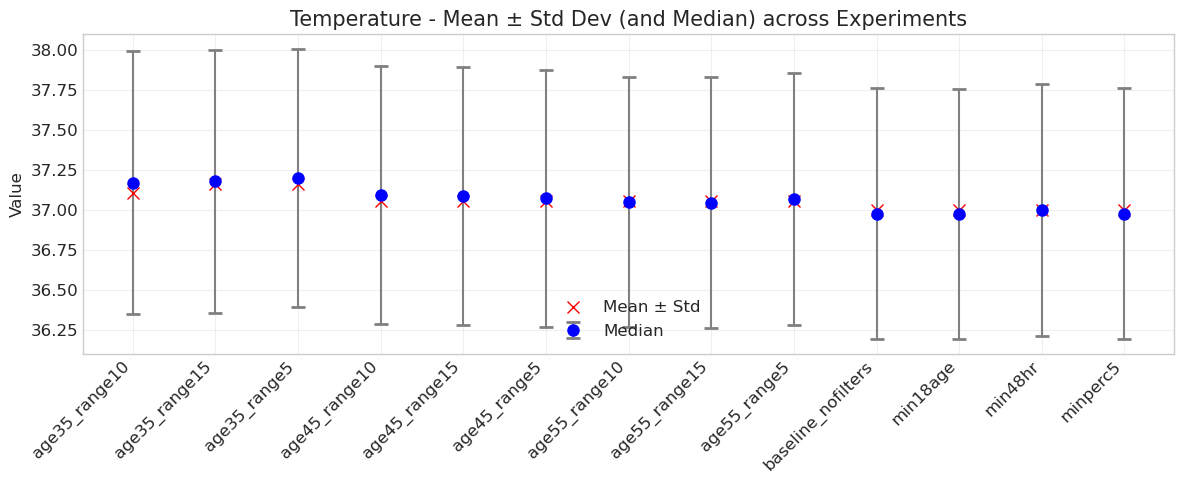

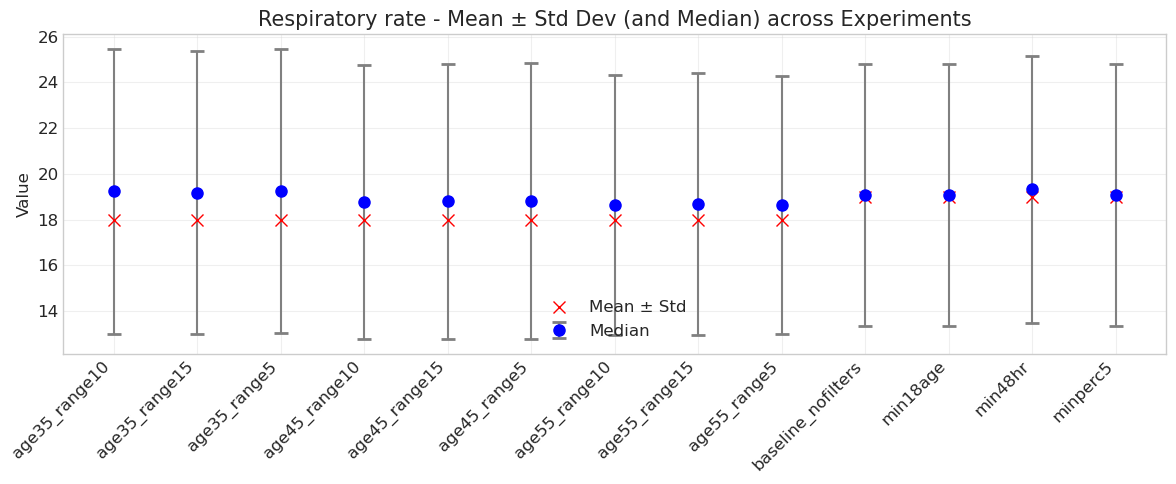

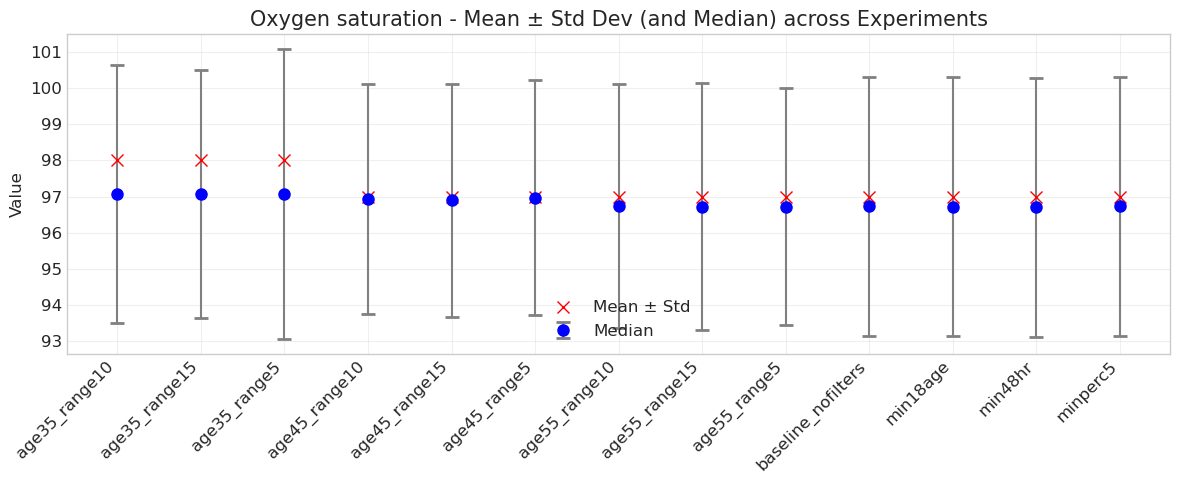

In [3]:
key_vitals = [
    'Heart Rate',
    'Systolic blood pressure',
    'Diastolic blood pressure',
    'Mean blood pressure',
    'Temperature',
    'Respiratory rate',
    'Oxygen saturation',
]

for vital in key_vitals:
    vital_stats = []
    target = vital.lower()
    for exp, data in stats.items():
        var_map = data.get('variables', {})
        v_data = var_map.get(target)
        if v_data is None:
            continue
        vital_stats.append({
            'Experiment': exp,
            'Mean': v_data['mean'],
            'Median': v_data['median'],
            'Std': v_data['std']
        })

    if not vital_stats:
        print(f'No data found for {vital}')
        continue

    df_v = pd.DataFrame(vital_stats).sort_values('Experiment')

    plt.figure(figsize=(12, 5))
    plt.errorbar(
        x=df_v['Experiment'],
        y=df_v['Mean'],
        yerr=df_v['Std'],
        fmt='o',
        capsize=5,
        capthick=2,
        markersize=8,
        color='b',
        ecolor='gray'
    )
    plt.plot(df_v['Experiment'], df_v['Median'], 'rx', markersize=8, label='Median')

    plt.xticks(rotation=45, ha='right')
    plt.title(f'{vital} - Mean ± Std Dev (and Median) across Experiments', fontsize=15)
    plt.ylabel('Value', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(['Mean ± Std', 'Median'])
    plt.tight_layout()
    plt.show()



## 3. Heatmap of Variable Means
To see how the mean values of all variables compare across experiments, we can plot a heatmap. We will normalize the values per variable (z-score) to make them comparable on the same color scale.

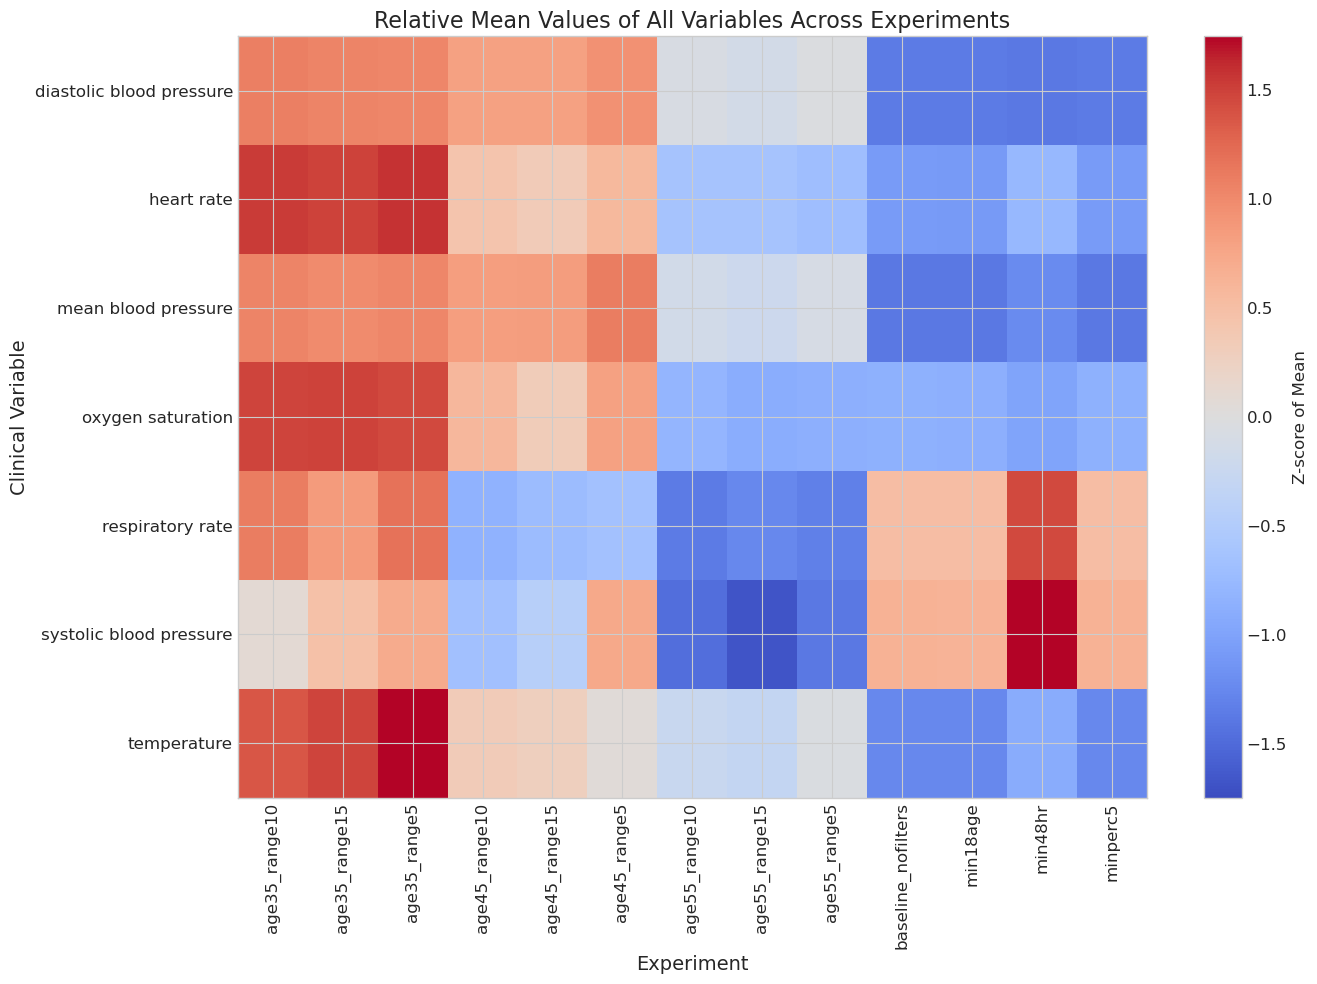

In [ ]:
# Build a dataframe of all means using the filtered experiment set
all_means = {}
for exp, data in stats.items():
    all_means[exp] = {var: vals['mean'] for var, vals in data['variables'].items()}

df_all_means = pd.DataFrame(all_means)

# Drop variables that have NaNs in any experiment to ensure a clean heatmap
df_all_means = df_all_means.dropna()

# Normalize row-wise (per variable) to see relative differences between experiments
def _zscore_row(x):
    s = x.std(ddof=0)
    if pd.isna(s) or s == 0:
        return x * 0
    return (x - x.mean()) / s

df_normalized = df_all_means.apply(_zscore_row, axis=1)

plt.figure(figsize=(14, 10))
sns.heatmap(df_normalized, cmap='coolwarm', center=0, cbar_kws={'label': 'Z-score of Mean'})
plt.title('Relative Mean Values of All Variables Across Experiments', fontsize=16)
plt.xlabel('Experiment', fontsize=14)
plt.ylabel('Clinical Variable', fontsize=14)
plt.tight_layout()
plt.show()


""" 
This z score is computed row-wise (per vital across experiments), not column-wise.
for each vital row (x): [ z_i = \frac{x_i - \mu_{\text{row}}}{\sigma_{\text{row}}} ] where:

    (x_i) = mean value of that vital in one experiment
    (\mu_{\text{row}}) = average of that vital’s means across all experiments
    (\sigma_{\text{row}}) = standard deviation of that vital’s means across all experiments
"""
